Dataset size: 500
First image path: /home/lc2762/segrefiner_multi/data/leftImg8bit/val/frankfurt/frankfurt_000000_000294_leftImg8bit.png
after mapping: [  0   1   2   3   4   5 255]


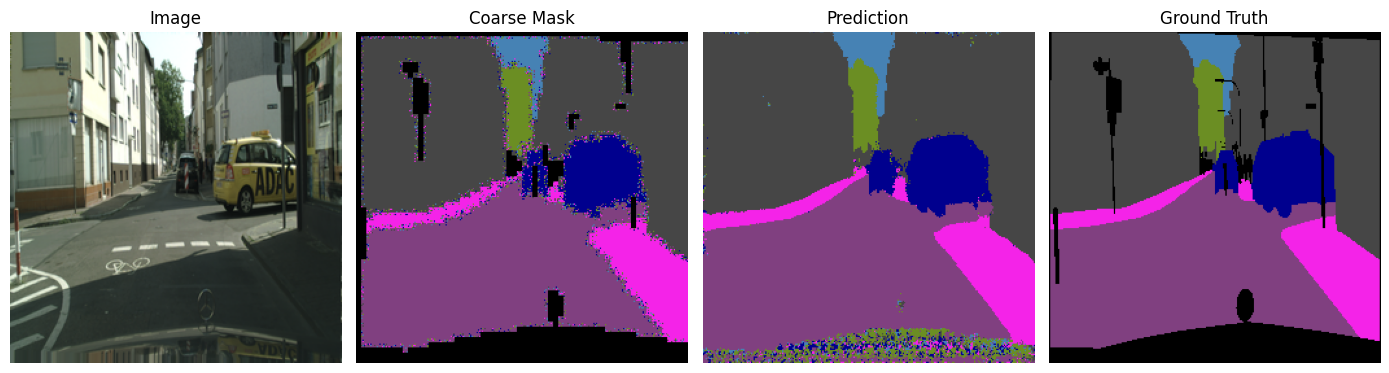

Visualization saved to vis_result.png


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from data import Cityscapes6ClassRefinement
from model import UNet_Diffusion

# ================================================================
# Device
# ================================================================
device = "cuda" if torch.cuda.is_available() else "cpu"

# ================================================================
# Paths and parameters
# ================================================================
ckpt_path = "/home/lc2762/segrefiner_multi/runs/checkpoints/model_epoch_100__akl1.0.pth"
data_root = "/home/lc2762/segrefiner_multi/data"

K = 6       # number of classes
T = 16      # diffusion steps

# ================================================================
# Cityscapes color palette for the selected 6 classes
# ================================================================
# Class order:
# 0: road, 1: sidewalk, 2: building, 3: vegetation, 4: sky, 5: car
CITYSCAPES_COLORS = np.array([
    [128, 64, 128],   # road
    [244, 35, 232],   # sidewalk
    [70, 70, 70],     # building
    [107, 142, 35],   # vegetation
    [70, 130, 180],   # sky
    [0, 0, 142],      # car
    [0, 0, 0],        # ignore (255)
], dtype=np.uint8)

def multi_step_refine(model, img, coarse, T):
    """
    img   : [1, 3, H, W]
    coarse: [1, H, W]
    return: pred [1, H, W]
    """
    xt = coarse.clone()

    with torch.no_grad():
        for step in reversed(range(1, T + 1)):
            t = torch.full((img.size(0),), step, device=img.device, dtype=torch.float32) / T
            logits = model(img, coarse, xt, t)
            xt = torch.argmax(logits, dim=1)

    return xt
def decode_segmap(mask, colors=CITYSCAPES_COLORS):
    """
    Convert a label mask to an RGB image using the Cityscapes palette.

    Args:
        mask: [H, W] numpy array with values in {0,...,K-1} and K for ignore.
    Returns:
        color_mask: [H, W, 3] RGB image.
    """
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)

    for label in range(len(colors)):
        color_mask[mask == label] = colors[label]

    return color_mask


# ================================================================
# Load model
# ================================================================
model = UNet_Diffusion(num_classes=K).to(device)

# Use weights_only=True to avoid FutureWarning (if supported by PyTorch version)
try:
    state_dict = torch.load(ckpt_path, map_location=device, weights_only=True)
except TypeError:
    state_dict = torch.load(ckpt_path, map_location=device)

model.load_state_dict(state_dict)
model.eval()

# ================================================================
# Load dataset (validation split)
# ================================================================
dataset = Cityscapes6ClassRefinement(root=data_root, split="val")
print("Dataset size:", len(dataset))
print("First image path:", dataset.images[0])

# Select one sample for visualization
img, coarse, gt = dataset[0]

img = img.unsqueeze(0).to(device)        # [1, 3, H, W]
coarse = coarse.unsqueeze(0).to(device)  # [1, H, W]
gt = gt.unsqueeze(0).to(device)          # [1, H, W]

# Diffusion timestep (consistent with training)
t = torch.ones(1, device=device)
t_norm = t / T
xt = coarse.clone()

# ================================================================
# Inference
# ================================================================
with torch.no_grad():
    logits = model(img, coarse, xt, t_norm)
    pred = torch.argmax(logits, dim=1)

# ================================================================
# Convert tensors to numpy
# ================================================================
# De-normalize image
img_np = img[0].cpu().permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = img_np * std + mean
img_np = np.clip(img_np, 0, 1)

coarse_np = coarse[0].cpu().numpy()
pred_np = pred[0].cpu().numpy()
gt_np = gt[0].cpu().numpy()

# Map ignore label (255) to color index K
coarse_show = coarse_np.copy()
gt_show = gt_np.copy()
coarse_show[coarse_show == 255] = K
gt_show[gt_show == 255] = K

# Decode segmentation masks to RGB
coarse_rgb = decode_segmap(coarse_show)
pred_rgb = decode_segmap(pred_np)
gt_rgb = decode_segmap(gt_show)

# ================================================================
# Visualization
# ================================================================
plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(img_np)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(coarse_rgb)
plt.title("Coarse Mask")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(pred_rgb)
plt.title("Prediction")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(gt_rgb)
plt.title("Ground Truth")
plt.axis("off")

plt.tight_layout()
plt.savefig("vis_result.png", dpi=300)
plt.show()

print("Visualization saved to vis_result.png")

Using checkpoint: /home/lc2762/segrefiner_multi/runs/checkpoints/model_epoch_50__akl1.0.pth
Dataset size: 500
Sample index: 0
Image path: /home/lc2762/segrefiner_multi/data/leftImg8bit/val/frankfurt/frankfurt_000000_000294_leftImg8bit.png
after mapping: [  0   1   2   3   4   5 255]
Coarse unique: [  0   1   2   3   4   5 255]
Pred unique: [0 1 2 3 4 5]
GT unique: [  0   1   2   3   4   5 255]


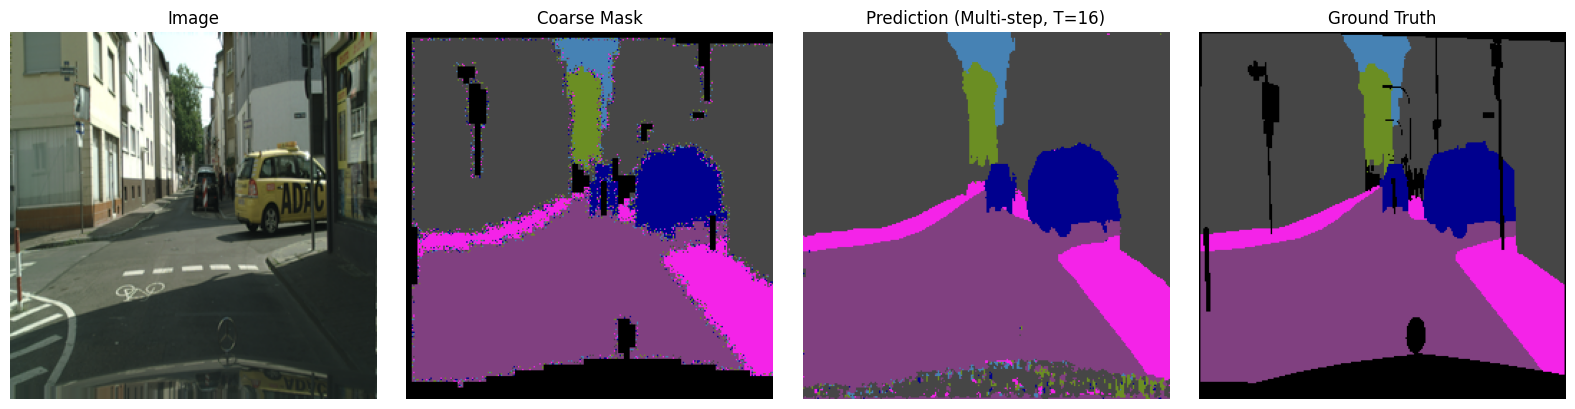

Saved main visualization to vis_result_multistep.png


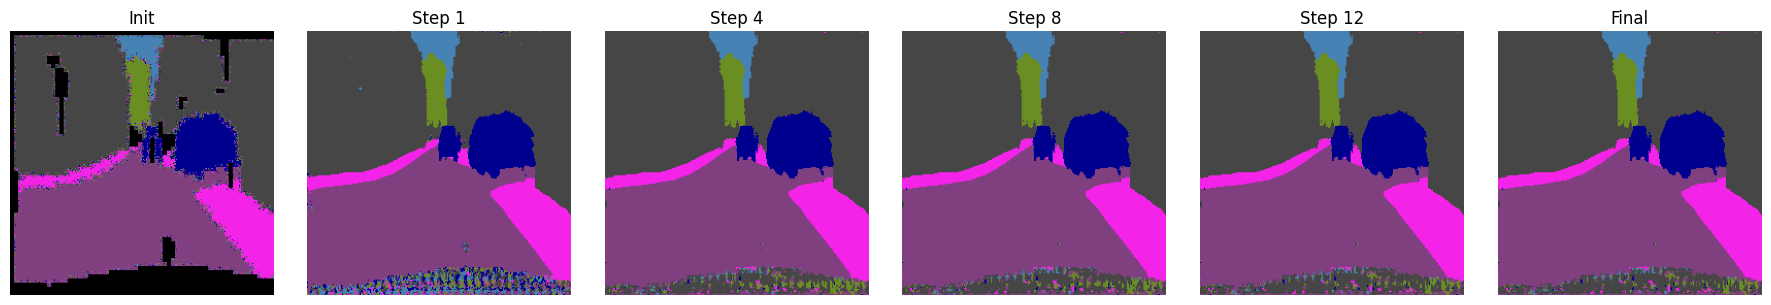

Saved trajectory visualization to vis_trajectory_multistep.png


In [4]:
import random
import torch
import numpy as np
import matplotlib.pyplot as plt

from data import Cityscapes6ClassRefinement
from model import UNet_Diffusion

# ================================================================
# Reproducibility
# ================================================================
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)

# ================================================================
# Device
# ================================================================
device = "cuda" if torch.cuda.is_available() else "cpu"

# ================================================================
# Paths and parameters
# ================================================================
ckpt_path = "/home/lc2762/segrefiner_multi/runs/checkpoints/model_epoch_50__akl1.0.pth"
data_root = "/home/lc2762/segrefiner_multi/data"

K = 6
T = 16
sample_idx = 0

# ================================================================
# Cityscapes color palette for selected 6 classes
# 0: road, 1: sidewalk, 2: building, 3: vegetation, 4: sky, 5: car
# 6: ignore
# ================================================================
CITYSCAPES_COLORS = np.array([
    [128, 64, 128],   # road
    [244, 35, 232],   # sidewalk
    [70, 70, 70],     # building
    [107, 142, 35],   # vegetation
    [70, 130, 180],   # sky
    [0, 0, 142],      # car
    [0, 0, 0],        # ignore
], dtype=np.uint8)


def decode_segmap(mask, colors=CITYSCAPES_COLORS):
    """
    Convert label mask to RGB image.
    mask: [H, W], with labels in {0,...,K-1} and K for ignore
    """
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for label in range(len(colors)):
        color_mask[mask == label] = colors[label]
    return color_mask


def denormalize_image(img_tensor):
    """
    img_tensor: [3, H, W]
    return: [H, W, 3] in [0,1]
    """
    img_np = img_tensor.cpu().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)
    return img_np


def multi_step_refine(model, img, coarse, T):
    """
    Multi-step deterministic refinement.

    Args:
        model : trained model
        img   : [1, 3, H, W]
        coarse: [1, H, W]
        T     : number of diffusion steps

    Returns:
        pred      : [1, H, W] final prediction
        traj_list : list of intermediate xt masks (numpy-ready tensors)
    """
    xt = coarse.clone()
    traj_list = [xt[0].detach().cpu().clone()]

    with torch.no_grad():
        for step in reversed(range(1, T + 1)):
            t = torch.full(
                (img.size(0),),
                step,
                device=img.device,
                dtype=torch.float32
            ) / T

            logits = model(img, coarse, xt, t)
            xt = torch.argmax(logits, dim=1)
            traj_list.append(xt[0].detach().cpu().clone())

    return xt, traj_list


# ================================================================
# Load model
# ================================================================
model = UNet_Diffusion(num_classes=K).to(device)

try:
    state_dict = torch.load(ckpt_path, map_location=device, weights_only=True)
except TypeError:
    state_dict = torch.load(ckpt_path, map_location=device)

model.load_state_dict(state_dict)
model.eval()

print("Using checkpoint:", ckpt_path)

# ================================================================
# Load dataset
# ================================================================
dataset = Cityscapes6ClassRefinement(root=data_root, split="val")
print("Dataset size:", len(dataset))
print("Sample index:", sample_idx)
print("Image path:", dataset.images[sample_idx])

img, coarse, gt = dataset[sample_idx]

img = img.unsqueeze(0).to(device)        # [1, 3, H, W]
coarse = coarse.unsqueeze(0).to(device)  # [1, H, W]
gt = gt.unsqueeze(0).to(device)          # [1, H, W]

# ================================================================
# Inference: multi-step refinement
# ================================================================
pred, traj_list = multi_step_refine(model, img, coarse, T)

# ================================================================
# Convert to numpy for visualization
# ================================================================
img_np = denormalize_image(img[0])

coarse_np = coarse[0].cpu().numpy()
pred_np = pred[0].cpu().numpy()
gt_np = gt[0].cpu().numpy()

print("Coarse unique:", np.unique(coarse_np))
print("Pred unique:", np.unique(pred_np))
print("GT unique:", np.unique(gt_np))

# ignore=255 -> color index K
coarse_show = coarse_np.copy()
gt_show = gt_np.copy()
coarse_show[coarse_show == 255] = K
gt_show[gt_show == 255] = K

pred_show = pred_np.copy()
pred_show[pred_show == 255] = K

coarse_rgb = decode_segmap(coarse_show)
pred_rgb = decode_segmap(pred_show)
gt_rgb = decode_segmap(gt_show)

# ================================================================
# Main 4-panel figure
# ================================================================
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(img_np)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(coarse_rgb)
plt.title("Coarse Mask")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(pred_rgb)
plt.title(f"Prediction (Multi-step, T={T})")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(gt_rgb)
plt.title("Ground Truth")
plt.axis("off")

plt.tight_layout()
plt.savefig("vis_result_multistep.png", dpi=300)
plt.show()

print("Saved main visualization to vis_result_multistep.png")

# ================================================================
# Optional: visualize selected intermediate steps
# ================================================================
# traj_list[0]   = initial coarse
# traj_list[-1]  = final prediction
show_steps = [0, 1, 4, 8, 12, 16] if T >= 16 else list(range(min(len(traj_list), 6)))

plt.figure(figsize=(3 * len(show_steps), 3))

for j, s in enumerate(show_steps):
    xt_np = traj_list[s].numpy()
    xt_show = xt_np.copy()
    xt_show[xt_show == 255] = K
    xt_rgb = decode_segmap(xt_show)

    plt.subplot(1, len(show_steps), j + 1)
    plt.imshow(xt_rgb)
    if s == 0:
        plt.title("Init")
    elif s == len(traj_list) - 1:
        plt.title("Final")
    else:
        plt.title(f"Step {s}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("vis_trajectory_multistep.png", dpi=300)
plt.show()

print("Saved trajectory visualization to vis_trajectory_multistep.png")